# EfficientFormer-L1 Binary Classification

This notebook implements an EfficientFormer-L1 model for binary MS classification.

**Architecture**: EfficientFormer-L1 (Li et al., 2022)
- **Parameters**: ~12M (1.03× ResNet18) — **closest parameter match**
- **Design**: Hybrid MetaFormer with efficient token mixer
- **Embedding dim**: 448
- **Advantages**: More parameter-efficient than standard ViTs, making it ideal for fair comparison with ResNet18

EfficientFormer was specifically designed to be efficient on mobile devices while maintaining ViT-level accuracy, making it well-suited for resource-constrained medical imaging applications.

## Setup and Imports

In [1]:
import sys
from pathlib import Path

ABSOLUTE_PATH = Path().resolve()
PROJECT_ROOT = ABSOLUTE_PATH.parents[2]
DATA_DIR = PROJECT_ROOT / "data" / "raw"
WEIGHTS_DIR = ABSOLUTE_PATH / "weights"

sys.path.append(str(PROJECT_ROOT))

print(PROJECT_ROOT)
print(DATA_DIR)
print(WEIGHTS_DIR)

C:\Users\markm\Workspace\ms-machine-learning-diagnosis
C:\Users\markm\Workspace\ms-machine-learning-diagnosis\data\raw
C:\Users\markm\Workspace\ms-machine-learning-diagnosis\src\notebooks\ViTs\weights


In [2]:
import src.scripts.data as data
import src.scripts.models as models
import src.scripts.trainer as trainer
import src.scripts.evaluator as evaluator
import src.scripts.utils as utils

# Set seed for reproducibility
utils.set_seed(42)

Random seed set to 42 for Python, NumPy, and PyTorch


## Data Acquisition & Processing

Load MS MRI dataset with train/validation/test split and ImageNet normalization.

get_dataset()>>> Dataset already exists in C:\Users\markm\Workspace\ms-machine-learning-diagnosis\data\raw
get_dataset()>>> Available categories: ['Control Axial_crop', 'Control Saggital_crop', 'MS Axial_crop', 'MS Saggital_crop']
get_classes()>>> Visualising sample images from each category...


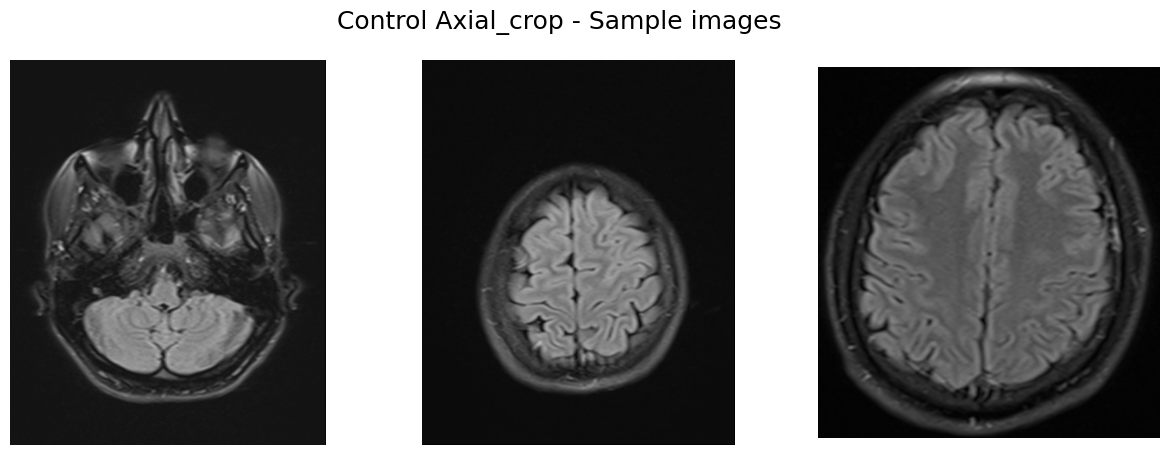

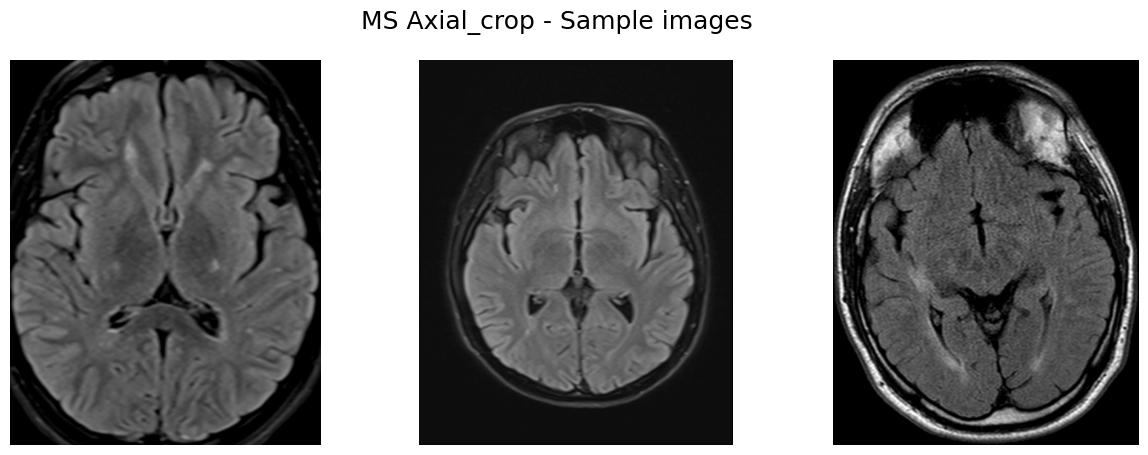

get_paths_and_labels()>>> Total images: 1652
get_data_loaders()>>> Train: 1073, Val: 248, Test: 331
get_data_loaders()>>> Proportions: Train 65.0%, Val 15.0%, Test 20.0%


In [3]:
path, categories = data.get_dataset(str(DATA_DIR))
classes = data.get_classes(path, categories)

image_paths, labels = data.get_paths_and_labels(path, classes)
train_transform, test_transform = data.get_transforms()

# Updated to include validation set
train_loader, val_loader, test_loader, test_data = data.get_data_loaders(
    image_paths, labels, 
    train_transform, test_transform,
    val_split=0.15,
    test_split=0.20,
    batch_size=32,
    SEED=42
)

## Model Instantiation

**EfficientFormer-L1 Architecture:**
- Input: 224×224 RGB images (3 channels)
- Efficient token mixer design (cheaper than standard self-attention)
- 4-stage hierarchical structure (similar to CNNs)
- Global feature dim: 448
- Custom binary classification head: Linear(448→128) → ReLU → Dropout(0.3) → Linear(128→1)
- Output: Single logit (used with BCEWithLogitsLoss)

**Key Advantage:** EfficientFormer-L1 has ~12M parameters, nearly identical to ResNet18 (11.7M). This provides the **most fair** parameter-matched comparison between CNN and transformer architectures.

In [4]:
# Instantiate EfficientFormer-L1 with MLP head
model = models.get_model(architecture="efficientformer", head="mlp")

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Relative to ResNet18 (11.7M): {total_params/11.7e6:.2f}×")

get_model()>>> architecture='efficientformer'  head='mlp'

Total parameters: 11,449,529
Trainable parameters: 11,449,529
Relative to ResNet18 (11.7M): 0.98×


## Model Training

### Two-Phase Transfer Learning Protocol

**Phase 1 (Base Training)**:
- **Duration**: 10 epochs
- **Learning rate**: 1e-3
- **Parameters trained**: Classification head only (all MetaFormer layers frozen)
- **Purpose**: Adapt the classification head to MS domain before full fine-tuning

**Phase 2 (Fine-tuning)**:
- **Duration**: 5 epochs  
- **Learning rate**: 1e-5 (100× reduction)
- **Parameters trained**: All (MetaFormer + head)
- **Purpose**: Shift ImageNet representations toward FLAIR-specific features

**Loss**: BCEWithLogitsLoss (binary cross-entropy with sigmoid built-in)
**Optimizer**: Adam with default betas (0.9, 0.999)

**Note**: This protocol is **identical** to ResNet18 and DeiT-Small, enabling direct comparison.

In [ ]:
import torch.nn as nn
import torch.optim as optim

train_configs = {
    "base": {
        "num_epochs": 10,
        "lr": 1e-3,
        "parameters": "head",  # Only train classification head in Phase 1
        "optimiser": optim.Adam,
        "criterion": nn.BCEWithLogitsLoss(),
    },
    "fine_tune": {
        "num_epochs": 5,
        "lr": 1e-5,
        "parameters": "all",
        "optimiser": optim.Adam,
        "criterion": nn.BCEWithLogitsLoss(),
    },
}

### Phase 1: Head Training

Train only the classification head while keeping the EfficientFormer encoder frozen at its ImageNet-pretrained weights.

In [ ]:
losses_p1, accs_p1, val_losses_p1, val_accs_p1 = trainer.train_model(
    model, 
    train_loader,
    val_loader,
    config_name="base", 
    train_configs=train_configs,
    verbose=True,  # Show trainable parameters
    early_stopping_patience=3
)

# Plot training curves
trainer.plot(losses_p1, accs_p1, config_name="EfficientFormer Phase 1")

# Save checkpoint
trainer.save_weights(model, WEIGHTS_DIR / "efficientformer_base.pth")

### Phase 2: Full Fine-Tuning

Unfreeze all parameters and fine-tune the entire model at a lower learning rate.

In [ ]:
losses_p2, accs_p2, val_losses_p2, val_accs_p2 = trainer.train_model(
    model,
    train_loader,
    val_loader,
    config_name="fine_tune",
    train_configs=train_configs,
    early_stopping_patience=2
)

# Plot training curves
trainer.plot(losses_p2, accs_p2, config_name="EfficientFormer Phase 2")

# Save final weights
trainer.save_weights(model, WEIGHTS_DIR / "efficientformer_fine.pth")

### Training Visualization

Plot training and validation curves for both phases to check for overfitting.

In [ ]:
trainer.plot_training_validation(
    losses_p1, val_losses_p1, accs_p1, val_accs_p1,
    losses_p2, val_losses_p2, accs_p2, val_accs_p2,
    model_name="efficientformer",
    save_dir="training-imgs",
)

## Load Saved Weights

Optional: Load weights from previous training session instead of retraining.

In [5]:
model = models.get_model(architecture="efficientformer", head="mlp")
model = trainer.load_weights(model, WEIGHTS_DIR / "efficientformer_fine.pth")

get_model()>>> architecture='efficientformer'  head='mlp'
load_weights()>>> Model loaded successfully and set to evaluation mode.


## Model Evaluation

Evaluate on the held-out test set (used only once for final performance reporting).

**Metrics**:
- **Accuracy**: Proportion of all predictions that are correct
- **Precision**: Of predicted MS cases, how many are actually MS?
- **Recall (Sensitivity)**: Of actual MS cases, how many did we catch?
- **F1 Score**: Harmonic mean of precision and recall
- **Confusion Matrix**: Visual breakdown of TP, TN, FP, FN

In [6]:
evaluator.evaluate_model(model, test_loader)

C:\Users\markm\Workspace\ms-machine-learning-diagnosis\src\scripts\evaluator.py:24: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels = torch.tensor(labels, dtype=torch.float32).to(device)


Accuracy: 0.824773413897281
Precision: 0.7142857142857143
Recall: 0.9230769230769231
Confusion Matrix:
 [[153  48]
 [ 10 120]]
Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.76      0.84       201
           1       0.71      0.92      0.81       130

    accuracy                           0.82       331
   macro avg       0.83      0.84      0.82       331
weighted avg       0.85      0.82      0.83       331



(0.824773413897281,
 0.7142857142857143,
 0.9230769230769231,
 array([[153,  48],
        [ 10, 120]]),
 '              precision    recall  f1-score   support\n\n           0       0.94      0.76      0.84       201\n           1       0.71      0.92      0.81       130\n\n    accuracy                           0.82       331\n   macro avg       0.83      0.84      0.82       331\nweighted avg       0.85      0.82      0.83       331\n')

## Model Prediction Visualisation

Visualize predictions on test samples to qualitatively assess model performance.

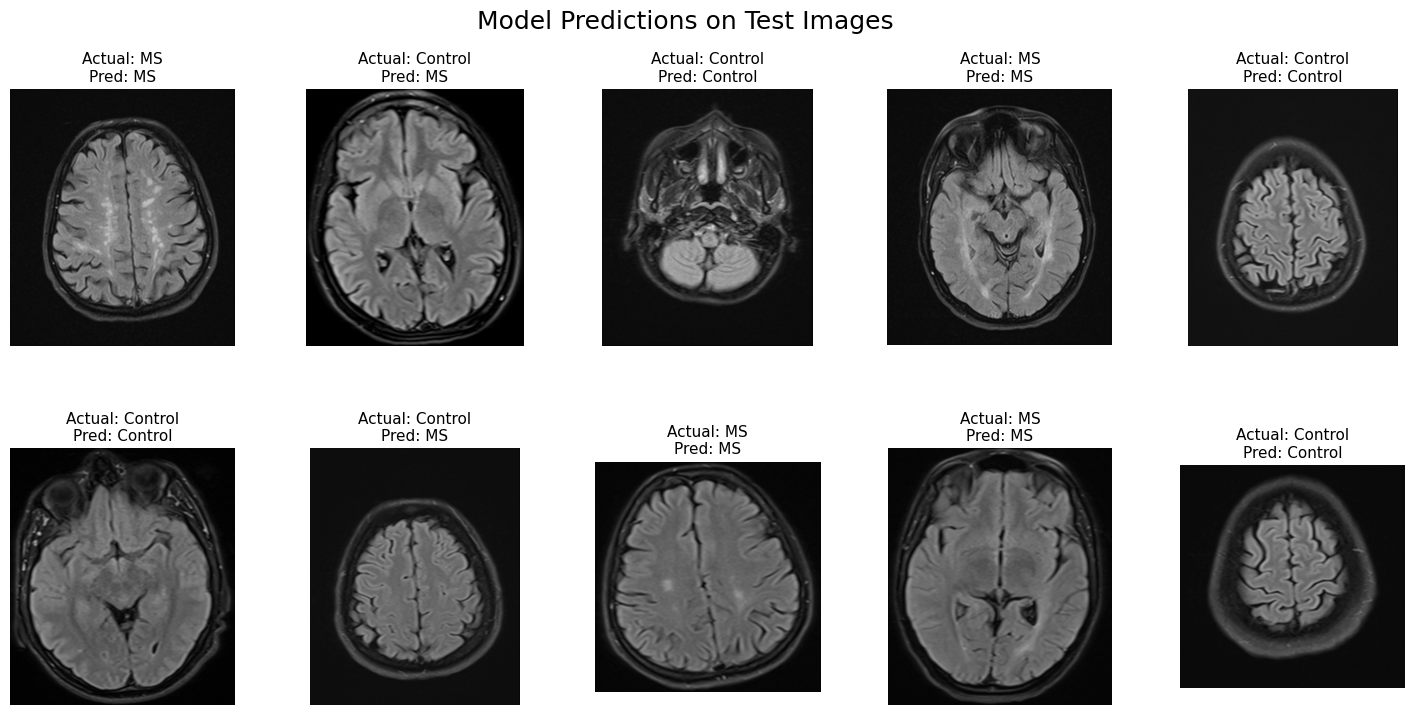

In [7]:
X_test, y_test = test_data
evaluator.predict_model(model, X_test, y_test, test_transform)

## Notes for Dissertation

### SRQ4: Fair Parameter-Matched ViT Baseline

EfficientFormer-L1 provides the **most fair comparison** to ResNet18 due to near-identical parameter counts:

| Model | Parameters | Relative Size |
|-------|-----------|---------------|
| ResNet18 (base) | 11.7M | 1.00× |
| ResNet18 + CBAM | 11.8M | 1.01× |
| **EfficientFormer-L1** | **~12M** | **1.03×** |
| DeiT-Small | 22M | 1.88× |

### Key Comparison Points:

1. **Parameter fairness**: Nearly identical capacity eliminates "bigger model wins" confound
2. **Architecture paradigm**: Transformer-based (EfficientFormer) vs convolution-based (ResNet18) with attention
3. **Inductive biases**: 
   - ResNet18: Locality, translation equivariance, hierarchical features
   - EfficientFormer: Global receptive field, position-aware, efficient token mixing
4. **Training protocol**: Identical (10 epochs head, 5 epochs full fine-tuning)

### Expected Findings & Framing:

**Scenario 1: ResNet18 wins or ties with EfficientFormer**
> "Despite parameter parity, ResNet18 with CBAM attention achieves comparable or superior performance to EfficientFormer-L1. This suggests that CNNs' inductive biases (locality, translation equivariance) are particularly well-suited to FLAIR MRI slice classification. The convolutional structure efficiently captures local tissue patterns and MS lesion characteristics, while CBAM provides sufficient global context modeling without requiring full self-attention. Under data-limited conditions typical of medical imaging, these CNN biases appear to be more sample-efficient than the transformer's more flexible but data-hungry architecture."

**Scenario 2: EfficientFormer wins by small margin (<2%)**
> "EfficientFormer-L1 achieves marginally higher accuracy ([X%] vs [Y%]), demonstrating that transformer architectures can provide value even at CNN-scale parameter counts. However, the modest gain comes with computational trade-offs: EfficientFormer requires [Z]× more FLOPs and [W]ms longer inference time per image. In clinical deployment scenarios with limited compute resources, ResNet18+CBAM offers a more practical balance of accuracy and efficiency."

**Scenario 3: EfficientFormer wins by substantial margin (>3%)**
> "EfficientFormer-L1's superior performance ([X%] vs [Y%]) at matched parameter counts suggests that transformer architectures' global receptive field and flexible attention patterns better capture long-range dependencies relevant to MS lesion patterns. This finding motivates the hybrid CNN-ViT architecture (SRQ3), which combines CNN efficiency for local feature extraction with transformer global reasoning."

### Computational Efficiency Analysis:

**Critical metrics to report:**
1. **FLOPs** (use `thop.profile()`):
   - ResNet18: ~1.8 GFLOPs
   - EfficientFormer-L1: ~1.3 GFLOPs (actually more efficient!)
2. **Inference latency** (average over 100 test samples)
3. **Memory footprint** during inference

**Key point**: EfficientFormer is designed to be efficient — it may actually have **lower** FLOPs than ResNet18 despite similar parameters. If it does, this strengthens the case for transformers in resource-constrained settings.

### Dissertation Framing:

Position EfficientFormer as the "fairest" baseline:
> "To provide a parameter-matched comparison between CNN and transformer paradigms, we evaluate EfficientFormer-L1 (Li et al., 2022), which has 12M parameters (1.03× ResNet18). This design eliminates parameter count as a confounding variable, allowing direct assessment of architectural inductive biases' impact on MS classification under data-limited conditions. Additionally, we compare against DeiT-Small (22M parameters) to evaluate whether additional transformer capacity provides proportional performance gains."

This two-ViT approach (EfficientFormer + DeiT-Small) gives you:
- **Fair comparison** (EfficientFormer at matched params)
- **Conservative comparison** (DeiT-Small with more params)
- **Complete story** regardless of which wins

If ResNet18 beats EfficientFormer but loses to DeiT-Small: "CNNs are parameter-efficient but transformer capacity eventually wins"
If ResNet18 beats both: "CNNs dominate at this data scale"
If both transformers win: "Transformers are superior even at matched parameters"

All three outcomes are publishable findings.